## Урок 6. Домашнее задание

### 6.1 Задание начального уровня

**Задание просто уровня** Дана матрица $A$, вычислите SVD разложение с помощью функции `numpy.linalg.svd`. Найдите [определитель](https://ru.wikipedia.org/wiki/Определитель ) матрицы $U$ с помощью функции `numpy.linalg.det`. Чему равен определитель?

In [3]:
from numpy.linalg import svd, det
import numpy as np
A = np.array([[3,2,2],[2,3,-2]])

# -- ВАШ КОД ТУТ --
U, S, Vt = np.linalg.svd(A)
print(U)
print(S)
print(Vt)
det = np.linalg.det(U)
print(det)

[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]
[5. 3.]
[[-7.07106781e-01 -7.07106781e-01 -6.47932334e-17]
 [-2.35702260e-01  2.35702260e-01 -9.42809042e-01]
 [-6.66666667e-01  6.66666667e-01  3.33333333e-01]]
-1.0000000000000004


### 6.2 Задание высокого уровня

В домашней работе предлагаю Вам немного поработать с изображениями (похожий трюк можно увидеть в этой [статье на хабре](https://habr.com/ru/post/275273/)). Для этого нужно установить модуль Pillow (если у вас Анаконда, то https://anaconda.org/anaconda/pillow)

<pre>
pip install Pillow
</pre>

Загрузим картинку в трёхмерный *numpy array* и отобразим её прямо в jupyter notebook.

<class 'numpy.ndarray'> (380, 509, 3)


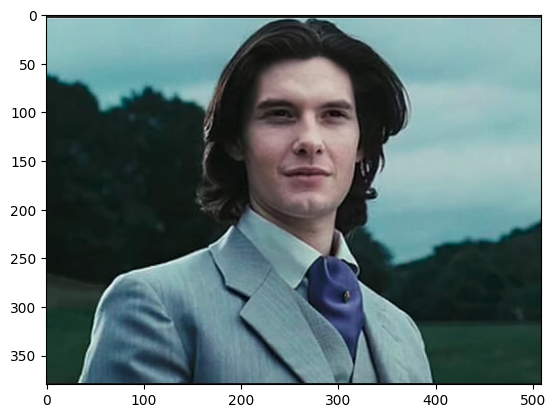

In [4]:
from matplotlib.pyplot import imshow
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('img/dorian_grey.png')
print(type(img),img.shape)
imshow(img)
plt.show()

У нас трёхмерный массив, где третье измерение соответствует цветовой компоненте rgb. Цветную картинку можно преобразовать в двумерную серую (grayscale) с помощью формулы, которую я нашёл [тут](https://stackoverflow.com/questions/12201577/how-can-i-convert-an-rgb-image-into-grayscale-in-python)

<class 'numpy.ndarray'> (380, 509)
[[0.13711765 0.13320001 0.13320001 ... 0.12144706 0.12144706 0.12144706]
 [0.13320001 0.13320001 0.13320001 ... 0.11752941 0.11752941 0.11752941]
 [0.13320001 0.13320001 0.12928236 ... 0.11752941 0.11752941 0.11752941]
 ...
 [0.18412942 0.18021177 0.17629412 ... 0.17237647 0.16845883 0.16845883]
 [0.18412942 0.18021177 0.17629412 ... 0.16192941 0.16192941 0.16192941]
 [0.12144706 0.11752941 0.11752941 ... 0.09402353 0.09402353 0.09402353]]
(380, 509)


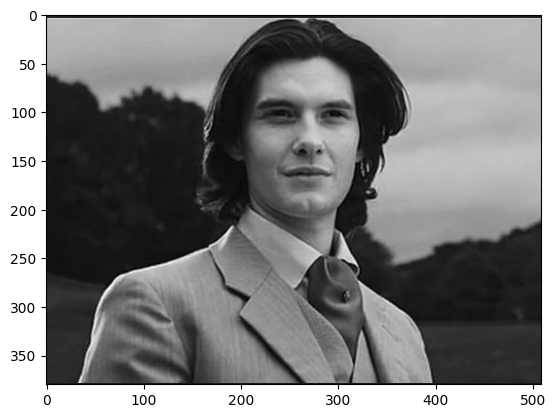

In [7]:
def rgb2gray(rgb):
  ''' Берётся среднее трёх цветов RGB'''
  tile = np.tile(np.c_[0.333, 0.333, 0.333], reps=(rgb.shape[0],rgb.shape[1],1))
  return np.sum(tile * rgb, axis=2)

img_gray = rgb2gray(img)
print(type(img_gray), img_gray.shape)
imshow(img_gray, cmap = "gray")
print(img_gray)
plt.show()

Далее

* обучите на массиве *img_gray* размерности $894 \times 588$ класс TruncatedSVD c параметром n_components=5
* получите матрицу *img_gray_svd* с помощью функции `transform`
* получите массив *img_gray_svd_restored* с помощью функции `inverse_transform`
* визуализируйте массив *img_gray_svd_restored* с помощью функции *imshow*

Этот алгоритм демонстрирует, как происходит сжатие данных большой размерности. А результате у вас должна получится фотка как бы в очень нечётком виде

![grey_pca.png](https://248006.selcdn.ru/public/DS.%20Block%202.%20M8/grey_pca.png)

В этом уроке мы познакомились с таким способом снижения размерности, как PCA. Оба метода которые мы же значем выполняют сжатие как линейное преобразование. В следующем уроке рассмотрим нелинейное сжатие

<class 'numpy.ndarray'> (380, 509)


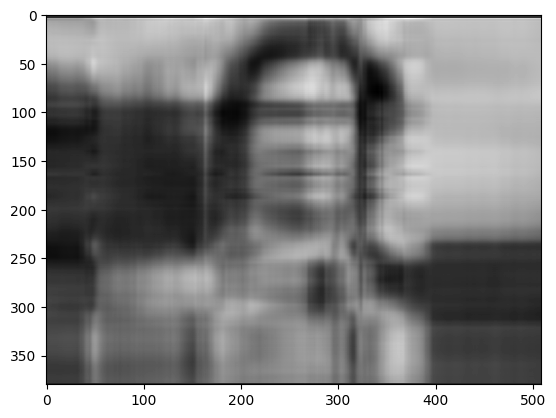

In [8]:
from sklearn.decomposition import TruncatedSVD

svd_model = TruncatedSVD(n_components=5).fit(img_gray)
img_gray_svd = svd_model.transform(img_gray)
img_gray_svd_restored = svd_model.inverse_transform(img_gray_svd)

print(type(img_gray_svd_restored), img_gray_svd_restored.shape)
imshow(img_gray_svd_restored, cmap = "gray")
plt.show()